# Analyze JobA

Sections:
1. **Setup** — imports, paths, model list.
2. **Loader** — single function that walks an output directory and returns a `DataFrame` keyed by `(category, model)`.
3. **§A — JobA aggregate (val_f1 default)**: per-cell table, per-model means/medians, per-cat winners + win counts, top-10 AUPR, hardest/easiest cats, per-defect recall, industrial metrics.
4. **§B — Clean ↔ val_defect comparison**: Tables A–D, sanity gates, threshold-shift summary.
5. **§C — Plots**: F1-lift bar chart, AUROC stability scatter, threshold-ratio histogram.

After the run, Tables A–D are also persisted as TSV under `data/outputs/jobA_val_defect_V1/_analysis/` (drop-in replacement for `compare_clean_vd.py`'s output).

## 1. Setup

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path
from statistics import mean, median, stdev

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent

OUTPUTS = REPO / "data" / "outputs"
JOBA_CLEAN_DIR = OUTPUTS / "JobA_v0"
JOBA_VD_DIR = OUTPUTS / "jobA_val_defect_V1"
ANALYSIS_DIR = JOBA_VD_DIR / "_analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_MODELS = ["anomalib_patchcore", "anomalib_padim", "subspacead"]
TRAINED_MODELS = ["anomalib_stfpm", "anomalib_csflow", "anomalib_draem", "rd4ad"]
ALL_MODELS = FEATURE_MODELS + TRAINED_MODELS

LEGACY_METRICS = [
    "auroc", "aupr", "f1", "precision", "recall", "accuracy",
    "ms_per_image", "fps", "peak_vram_mb", "fit_seconds", "predict_seconds",
    "threshold_used", "threshold_mode",
    "train_samples", "val_samples", "test_samples",
    "val_precision", "val_recall", "val_f1", "val_auroc", "val_aupr",
]
INDUSTRIAL_METRICS = [
    "recall_at_fpr_1pct", "recall_at_fpr_5pct",
    "macro_recall", "weighted_recall",
]
ALL_METRICS = LEGACY_METRICS + INDUSTRIAL_METRICS

print(f"Repo:         {REPO}")
print(f"Clean baseline (JobA_v0):     {JOBA_CLEAN_DIR.exists()} -> {JOBA_CLEAN_DIR}")
print(f"val_defect rerun (V1):        {JOBA_VD_DIR.exists()} -> {JOBA_VD_DIR}")

Repo:         C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection
Clean baseline (JobA_v0):     True -> C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\JobA_v0
val_defect rerun (V1):        True -> C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobA_val_defect_V1


## 2. Loader

Walks a directory whose subfolders look like `<prefix><category>_<UTC>/benchmark_summary.json`. The category is the substring between the prefix and the timestamp suffix. Returns a tidy `DataFrame` with one row per `(category, model)` cell.

Notes:
- `csflow` / `stfpm` / `draem` / `rd4ad` are *trained* models that ran model-major (one model at a time per category). They use a different prefix (`jobA_anomalib_<adapter>_<cat>_...`) so they are filtered out of the feature-based aggregation by default. Pass `models=TRAINED_MODELS` to ingest them.
- When the same `(cat, model)` pair has multiple timestamps, the freshest one wins.

In [2]:
_TS_TAIL = r"_\d{8}_\d{6}$"


def _category_from_dirname(dirname: str, prefix: str) -> str | None:
    pattern = rf"^{re.escape(prefix)}(.+){_TS_TAIL}"
    m = re.match(pattern, dirname)
    return m.group(1) if m else None


def load_runs(
    directory: Path,
    prefix: str,
    models: list[str] = FEATURE_MODELS,
    skip_substrings: tuple[str, ...] = (),
) -> pd.DataFrame:
    """Walk `directory` and return one row per (category, model) freshest run.

    `prefix` is the directory-name prefix that identifies the run family
    (e.g. ``jobA_``, ``jobA_val_defect_``, ``jobA_anomalib_csflow_``).
    """
    rows: dict[tuple[str, str], dict] = {}
    if not directory.exists():
        return pd.DataFrame()
    for d in sorted(directory.iterdir()):
        if not d.is_dir():
            continue
        name = d.name
        if any(s in name for s in skip_substrings):
            continue
        category = _category_from_dirname(name, prefix)
        if category is None:
            continue
        fp = d / "benchmark_summary.json"
        if not fp.exists():
            continue
        data = json.loads(fp.read_text())
        split = data.get("dataset", {}).get("split", {})
        for entry in data.get("models", []):
            mdl = entry.get("model")
            if mdl not in models:
                continue
            key = (category, mdl)
            prev = rows.get(key)
            if prev is not None and prev["_dir"] >= name:
                continue
            row = {"category": category, "model": mdl, "_dir": name,
                   "run_id": data.get("run", {}).get("run_id")}
            for k in ALL_METRICS:
                row[k] = entry.get(k)
            row["per_defect_recall"] = entry.get("per_defect_recall") or {}
            row["per_defect_support"] = entry.get("per_defect_support") or {}
            row["split_val_balance"] = split.get("val_balance")
            row["split_min_train_goods"] = split.get("min_train_goods")
            rows[key] = row
    df = pd.DataFrame(rows.values())
    if not df.empty:
        df = df.sort_values(["category", "model"]).reset_index(drop=True)
    return df


# Skip val_defect dirs and the trained-model dirs when ingesting clean JobA.
df_clean = load_runs(
    JOBA_CLEAN_DIR,
    prefix="jobA_",
    models=FEATURE_MODELS,
    skip_substrings=("val_defect", "_anomalib_", "_rd4ad_"),
)

df_vd = load_runs(
    JOBA_VD_DIR,
    prefix="jobA_val_defect_",
    models=FEATURE_MODELS,
    skip_substrings=("_anomalib_csflow_", "_anomalib_stfpm_", "_anomalib_draem_", "_rd4ad_"),
)

# Optional: trained-model results (currently only csflow audiojack on HPC).
df_trained = pd.DataFrame()
for adapter in TRAINED_MODELS:
    pf = f"jobA_{adapter}_"
    df_trained = pd.concat([
        df_trained,
        load_runs(JOBA_VD_DIR, prefix=pf, models=[adapter]),
        load_runs(JOBA_CLEAN_DIR, prefix=pf, models=[adapter]),
    ], ignore_index=True)

print(f"clean cells:      {len(df_clean):3d}  ({df_clean['category'].nunique()} cats x {df_clean['model'].nunique()} models)")
print(f"val_defect cells: {len(df_vd):3d}  ({df_vd['category'].nunique()} cats x {df_vd['model'].nunique()} models)")
print(f"trained cells:    {len(df_trained):3d}  ({df_trained['category'].nunique() if not df_trained.empty else 0} cats x {df_trained['model'].nunique() if not df_trained.empty else 0} adapters)")

clean cells:       90  (30 cats x 3 models)
val_defect cells:  90  (30 cats x 3 models)
trained cells:     52  (30 cats x 4 adapters)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_28664\3072874327.py:80: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_trained = pd.concat([
C:\Users\Usuario\AppData\Local\Temp\ipykernel_28664\3072874327.py:80: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_trained = pd.concat([
C:\Users\Usuario\AppData\Local\Temp\ipykernel_28664\3072874327.py:80: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude 

## §A — JobA aggregate (val_f1 baseline)

Same outputs as `analyze_runs.py --prefix jobA_val_defect_` plus the legacy `analyze_jobA.py` extras (top-10 AUPR, hardest/easiest, per-defect recall). Run on `df_vd` because that is the current methodology baseline (val_f1 + patched splitter).

In [3]:
active = df_vd  # change to df_clean to inspect the legacy val_quantile baseline.

print(f"Inspecting {len(active)} cells from {active['category'].nunique()} categories.")
active[["category", "model"] + LEGACY_METRICS[:6] + INDUSTRIAL_METRICS].head(12)

Inspecting 90 cells from 30 categories.


,category,model,auroc,aupr,f1,precision,recall,accuracy,recall_at_fpr_1pct,recall_at_fpr_5pct,macro_recall,weighted_recall
0,audiojack,anomalib_padim,0.898816,0.974897,0.882353,0.974026,0.806452,0.822695,0.227957,0.615054,0.806641,0.806452
1,audiojack,anomalib_patchcore,0.728381,0.926891,0.907258,0.853890,0.967742,0.836879,0.286022,0.307527,0.967857,0.967742
2,audiojack,subspacead,0.841403,0.957458,0.835113,0.931217,0.756989,0.753546,0.260215,0.374194,0.757792,0.756989
3,bottle_cap,anomalib_padim,0.932968,0.970062,0.969631,0.965443,0.973856,0.949821,0.002179,0.455338,0.974097,0.973856
4,bottle_cap,anomalib_patchcore,0.927576,0.982272,0.927536,0.949772,0.906318,0.883513,0.418301,0.607843,0.906125,0.906318
5,bottle_cap,subspacead,0.866288,0.968384,0.873143,0.918269,0.832244,0.801075,0.318083,0.594771,0.831595,0.832244
6,button_battery,anomalib_padim,0.895510,0.958508,0.902186,0.970297,0.843011,0.848754,0.025806,0.337634,0.846986,0.843011
7,button_battery,anomalib_patchcore,0.895023,0.976511,0.903226,0.935484,0.873118,0.845196,0.546237,0.634409,0.871956,0.873118
8,button_battery,subspacead,0.859993,0.968764,0.898925,0.898925,0.898925,0.832740,0.496774,0.578495,0.897799,0.898925
9,end_cap,anomalib_padim,0.796524,0.934228,0.906351,0.913232,0.899573,0.846018,0.061966,0.113248,0.903314,0.899573


In [4]:
# Per-model aggregates (means + medians).
agg_cols_mean = [
    "auroc", "aupr", "f1", "precision", "recall",
    "recall_at_fpr_1pct", "recall_at_fpr_5pct",
    "macro_recall", "weighted_recall",
    "ms_per_image", "fps", "peak_vram_mb", "fit_seconds",
]
per_model_mean = active.groupby("model")[agg_cols_mean].mean().round(4)
per_model_median = active.groupby("model")[["auroc", "aupr", "f1", "recall_at_fpr_1pct", "macro_recall"]].median().round(4)

print("=== PER-MODEL MEANS ===")
print(per_model_mean.to_string())
print("\n=== PER-MODEL MEDIANS ===")
print(per_model_median.to_string())

=== PER-MODEL MEANS ===
                     auroc    aupr      f1  precision  recall  recall_at_fpr_1pct  recall_at_fpr_5pct  macro_recall  weighted_recall  ms_per_image       fps  peak_vram_mb  fit_seconds
model                                                                                                                                                                                  
anomalib_padim      0.9022  0.9729  0.9287     0.9484  0.9129              0.2157              0.5889        0.9056           0.9040       10.2126  101.0182     4480.3271       9.9269
anomalib_patchcore  0.8701  0.9678  0.9046     0.9308  0.8843              0.3364              0.4898        0.8731           0.8732      113.5760   10.5325    13968.8689     482.8639
subspacead          0.8615  0.9662  0.8811     0.9298  0.8426              0.3507              0.4968        0.8182           0.8192      103.3303    9.6933     1786.4063      71.1687

=== PER-MODEL MEDIANS ===
                     auroc   

In [5]:
# Per-category AUROC table + winner counts.
pivot_auroc = active.pivot(index="category", columns="model", values="auroc").round(3)
pivot_auroc["winner"] = pivot_auroc.idxmax(axis=1).str.replace("anomalib_", "", regex=False)
print("=== PER-CATEGORY AUROC ===")
print(pivot_auroc.to_string())

wins = pivot_auroc["winner"].value_counts()
print("\nWIN COUNT (best AUROC per category):")
print(wins.to_string())

=== PER-CATEGORY AUROC ===
model              anomalib_padim  anomalib_patchcore  subspacead      winner
category                                                                     
audiojack                   0.899               0.728       0.841       padim
bottle_cap                  0.933               0.928       0.866       padim
button_battery              0.896               0.895       0.860       padim
end_cap                     0.797               0.851       0.827   patchcore
eraser                      0.983               0.857       0.797       padim
fire_hood                   0.981               0.818       0.832       padim
mint                        0.727               0.772       0.802  subspacead
mounts                      0.935               0.846       0.887       padim
pcb                         0.919               0.923       0.895   patchcore
phone_battery               0.788               0.935       0.860   patchcore
plastic_nut                 0.975    

In [6]:
# Top-10 categories by mean AUPR across the 3 models.
ranked_aupr = active.groupby("category")["aupr"].mean().sort_values(ascending=False)
print("=== TOP-10 CATEGORIES BY MEAN AUPR ===")
print(ranked_aupr.head(10).round(4).to_string())

ranked_auroc = active.groupby("category")["auroc"].mean().sort_values()
print("\n=== 5 HARDEST CATEGORIES BY MEAN AUROC ===")
print(ranked_auroc.head(5).round(4).to_string())
print("\n=== 5 EASIEST CATEGORIES BY MEAN AUROC ===")
print(ranked_auroc.tail(5).round(4).to_string())

=== TOP-10 CATEGORIES BY MEAN AUPR ===
category
zipper               0.9946
rolled_strip_base    0.9944
sim_card_set         0.9905
transistor1          0.9866
switch               0.9830
terminalblock        0.9818
usb_adaptor          0.9810
toothbrush           0.9805
toy                  0.9781
pcb                  0.9779

=== 5 HARDEST CATEGORIES BY MEAN AUROC ===
category
regulator    0.7249
mint         0.7669
woodstick    0.7771
toy_brick    0.7782
usb          0.8132

=== 5 EASIEST CATEGORIES BY MEAN AUROC ===
category
usb_adaptor          0.9265
transistor1          0.9486
sim_card_set         0.9735
rolled_strip_base    0.9765
zipper               0.9788


In [7]:
# Per-defect recall — long-form table (only cells that carry per_defect_recall).
pdef = []
for _, r in active.iterrows():
    per = r["per_defect_recall"] or {}
    sup = r["per_defect_support"] or {}
    for dtype in sorted(per.keys()):
        pdef.append({
            "category": r["category"],
            "model": r["model"].replace("anomalib_", ""),
            "defect_type": dtype,
            "support": sup.get(dtype, 0),
            "recall": per[dtype],
        })
df_perdef = pd.DataFrame(pdef)
print(f"Per-defect rows: {len(df_perdef)}")
df_perdef.head(15)

Per-defect rows: 267


,category,model,defect_type,support,recall
0,audiojack,padim,BX,115,0.965217
1,audiojack,padim,HS,117,0.940171
2,audiojack,padim,QS,116,0.577586
3,audiojack,padim,ZW,117,0.743590
4,audiojack,patchcore,BX,115,1.000000
5,audiojack,patchcore,HS,117,0.974359
6,audiojack,patchcore,QS,116,0.956897
7,audiojack,patchcore,ZW,117,0.940171
8,audiojack,subspacead,BX,115,1.000000
9,audiojack,subspacead,HS,117,0.623932


## §B — Clean ↔ val_defect comparison

Tables A–D from [PLAN job A_analize val_defect.md §6](../PLAN%20job%20A_analize%20val_defect.md). Same logic as `compare_clean_vd.py`, just rendered as DataFrames so the cells are inspectable inline.

In [8]:
# Join clean ↔ val_defect on (category, model). Inner join restricts to cells
# present in both — those are the ones the comparison is meaningful for.
renamed = lambda df, suffix: df.rename(columns={c: f"{c}_{suffix}"
                                                for c in df.columns
                                                if c not in ("category", "model")})
merged = df_clean.merge(df_vd, on=["category", "model"], how="inner",
                        suffixes=("_clean", "_vd"))

for col in ("auroc", "aupr", "f1", "precision", "recall", "threshold_used",
            "recall_at_fpr_1pct", "recall_at_fpr_5pct", "macro_recall"):
    merged[f"d{col}"] = merged[f"{col}_vd"] - merged[f"{col}_clean"]

print(f"Paired (cat, model) cells: {len(merged)}")
missing_in_clean = sorted(set(zip(df_vd['category'], df_vd['model'])) -
                          set(zip(df_clean['category'], df_clean['model'])))
if missing_in_clean:
    print("WARNING: vd cells without a clean baseline:")
    for x in missing_in_clean:
        print("  ", x)

Paired (cat, model) cells: 90


In [9]:
# Table A — per (category, model) full deltas.
table_A_cols = [
    "category", "model",
    "auroc_clean", "auroc_vd", "dauroc",
    "aupr_clean", "aupr_vd", "daupr",
    "f1_clean", "f1_vd", "df1",
    "precision_clean", "precision_vd",
    "recall_clean", "recall_vd",
    "threshold_used_clean", "threshold_used_vd",
    "val_recall_vd",
]
table_A = merged[table_A_cols].copy().round(4)
table_A.to_csv(ANALYSIS_DIR / "tableA_per_cat_model.tsv", sep="\t", index=False)
print(f"Table A: {len(table_A)} rows  ->  {ANALYSIS_DIR / 'tableA_per_cat_model.tsv'}")
table_A

Table A: 90 rows  ->  C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobA_val_defect_V1\_analysis\tableA_per_cat_model.tsv


,category,model,auroc_clean,auroc_vd,dauroc,aupr_clean,aupr_vd,daupr,f1_clean,f1_vd,df1,precision_clean,precision_vd,recall_clean,recall_vd,threshold_used_clean,threshold_used_vd,val_recall_vd
0,audiojack,anomalib_padim,0.9075,0.8988,-0.0087,0.9790,0.9749,-0.0041,0.7458,0.8824,0.1365,0.9811,0.9740,0.6015,0.8065,41.0820,47.2927,0.8462
1,audiojack,anomalib_patchcore,0.6920,0.7284,0.0363,0.9261,0.9269,0.0008,0.4697,0.9073,0.4375,0.9938,0.8539,0.3075,0.9677,39.7766,32.9617,1.0000
2,audiojack,subspacead,0.8383,0.8414,0.0031,0.9610,0.9575,-0.0036,0.4468,0.8351,0.3883,0.9933,0.9312,0.2882,0.7570,20.1938,5.7103,0.8846
3,bottle_cap,anomalib_padim,0.8803,0.9330,0.0527,0.9596,0.9701,0.0104,0.2276,0.9696,0.7420,0.9565,0.9654,0.1292,0.9739,47.2684,46.8965,0.9615
4,bottle_cap,anomalib_patchcore,0.9701,0.9276,-0.0426,0.9939,0.9823,-0.0116,0.7588,0.9275,0.1687,0.9968,0.9498,0.6125,0.9063,29.9050,31.7726,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,woodstick,anomalib_patchcore,0.6119,0.6588,0.0469,0.8951,0.9064,0.0113,0.1025,0.8969,0.7944,1.0000,0.8160,0.0540,0.9956,54.1372,35.3007,1.0000
86,woodstick,subspacead,0.7187,0.7966,0.0780,0.9298,0.9440,0.0142,0.3108,0.8879,0.5771,1.0000,0.8869,0.1840,0.8889,11.5847,2.2429,0.9200
87,zipper,anomalib_padim,0.9559,0.9575,0.0016,0.9903,0.9887,-0.0016,0.5795,0.9589,0.3794,1.0000,0.9579,0.4080,0.9600,55.4659,27.2415,0.9400
88,zipper,anomalib_patchcore,0.9839,0.9846,0.0007,0.9967,0.9964,-0.0002,0.8967,0.9593,0.0626,0.9951,0.9770,0.8160,0.9422,36.4313,30.8638,0.9800


In [10]:
# Table B — per-model headline (means across paired cells).
def _per_model(df: pd.DataFrame, agg="mean") -> pd.DataFrame:
    g = df.groupby("model")
    if agg == "mean":
        return g[["auroc_clean", "auroc_vd", "dauroc",
                  "aupr_clean", "aupr_vd", "daupr",
                  "f1_clean", "f1_vd", "df1",
                  "recall_clean", "recall_vd", "drecall",
                  "precision_clean", "precision_vd"]].mean().round(4)
    return g[["f1_clean", "f1_vd", "recall_clean", "recall_vd"]].median().round(4)

table_B_mean = _per_model(merged, "mean")
table_B_median = _per_model(merged, "median")

table_B = table_B_mean.copy()
for col in ("f1", "recall"):
    for side in ("clean", "vd"):
        table_B[f"{col}_{side}_median"] = table_B_median[f"{col}_{side}"]
table_B.insert(0, "n", merged.groupby("model").size())
table_B.to_csv(ANALYSIS_DIR / "tableB_per_model.tsv", sep="\t")
print(f"Table B  ->  {ANALYSIS_DIR / 'tableB_per_model.tsv'}")
table_B

Table B  ->  C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobA_val_defect_V1\_analysis\tableB_per_model.tsv


,n,auroc_clean,auroc_vd,dauroc,aupr_clean,aupr_vd,daupr,f1_clean,f1_vd,df1,recall_clean,recall_vd,drecall,precision_clean,precision_vd,f1_clean_median,f1_vd_median,recall_clean_median,recall_vd_median
model,,,,,,,,,,,,,,,,,,,
anomalib_padim,30,0.8928,0.9022,0.0094,0.9727,0.9729,0.0002,0.4754,0.9287,0.4533,0.3571,0.9129,0.5559,0.9872,0.9484,0.5452,0.9326,0.3758,0.9235
anomalib_patchcore,30,0.8701,0.8701,-0.0000,0.9712,0.9678,-0.0034,0.6066,0.9046,0.2980,0.4782,0.8843,0.4062,0.9924,0.9308,0.6045,0.9065,0.4347,0.8873
subspacead,30,0.8415,0.8615,0.0200,0.9643,0.9662,0.0020,0.5912,0.8811,0.2899,0.4581,0.8426,0.3845,0.9871,0.9298,0.6010,0.8871,0.4325,0.8415


In [11]:
# Table C — threshold shift summary.
merged["thr_ratio"] = merged["threshold_used_vd"] / merged["threshold_used_clean"]
table_C = merged.groupby("model")["thr_ratio"].agg(
    n="count", ratio_mean="mean", ratio_median="median",
    ratio_std="std", ratio_min="min", ratio_max="max",
).round(3)
table_C.to_csv(ANALYSIS_DIR / "tableC_threshold_shift.tsv", sep="\t")
print(f"Table C  ->  {ANALYSIS_DIR / 'tableC_threshold_shift.tsv'}")
table_C

Table C  ->  C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobA_val_defect_V1\_analysis\tableC_threshold_shift.tsv

,n,ratio_mean,ratio_median,ratio_std,ratio_min,ratio_max
model,,,,,,
anomalib_padim,30,0.690,0.595,0.336,0.258,1.372
anomalib_patchcore,30,0.925,0.929,0.140,0.652,1.238
subspacead,30,0.425,0.308,0.256,0.194,1.064


In [12]:
# Table D — val-set sanity (val_defect only).
table_D_cols = ["category", "model", "val_samples",
                "val_precision", "val_recall", "val_f1",
                "val_auroc", "val_aupr", "threshold_used"]
table_D = df_vd[table_D_cols].copy().round(4)
table_D.to_csv(ANALYSIS_DIR / "tableD_val_sanity.tsv", sep="\t", index=False)
print(f"Table D  ->  {ANALYSIS_DIR / 'tableD_val_sanity.tsv'}")
table_D.head(12)

Table D  ->  C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobA_val_defect_V1\_analysis\tableD_val_sanity.tsv


,category,model,val_samples,val_precision,val_recall,val_f1,val_auroc,val_aupr,threshold_used
0,audiojack,anomalib_padim,92,0.8800,0.8462,0.8627,0.9019,0.9351,47.2927
1,audiojack,anomalib_patchcore,92,0.6420,1.0000,0.7820,0.7284,0.8069,32.9617
2,audiojack,subspacead,92,0.8070,0.8846,0.8440,0.8736,0.8979,5.7103
3,bottle_cap,anomalib_padim,92,0.9259,0.9615,0.9434,0.9221,0.8552,46.8965
4,bottle_cap,anomalib_patchcore,92,0.8387,1.0000,0.9123,0.9558,0.9647,31.7726
5,bottle_cap,subspacead,92,0.7931,0.8846,0.8364,0.8822,0.9205,4.9164
6,button_battery,anomalib_padim,91,0.9423,0.9423,0.9423,0.9418,0.9631,50.6541
7,button_battery,anomalib_patchcore,91,0.8333,0.9615,0.8929,0.9152,0.9287,36.6005
8,button_battery,subspacead,91,0.7581,0.9038,0.8246,0.8279,0.8808,4.4598
9,end_cap,anomalib_padim,91,0.7015,0.9038,0.7899,0.7623,0.7927,34.8719


In [13]:
# Sanity gates from PLAN §8.4.
def _gates(merged: pd.DataFrame, vd: pd.DataFrame) -> None:
    print("=== SANITY GATES ===")
    zero_val = vd[vd["val_recall"].fillna(0) == 0][["category", "model", "val_recall"]]
    print(f"[1] cells with val_recall == 0 : {len(zero_val)}")
    if not zero_val.empty:
        print(zero_val.to_string(index=False))

    da = merged["dauroc"].abs()
    print(f"[2] |dAUROC| median = {da.median():.4f} (target < 0.01)")
    print(f"    |dAUROC| mean   = {da.mean():.4f}")
    print(f"    |dAUROC| max    = {da.max():.4f}")

    print("[3] per-category models with df1 > 0:")
    cat_df1 = merged.groupby("category")["df1"].apply(lambda s: (s > 0).sum())
    cat_n = merged.groupby("category")["df1"].count()
    fails = []
    for cat in sorted(merged["category"].unique()):
        wins = int(cat_df1[cat]); tot = int(cat_n[cat])
        flag = "  <-- FAIL" if wins < 2 else ""
        if wins < 2:
            fails.append(cat)
        print(f"    {cat:20s}  {wins}/{tot}{flag}")
    print(f"    cats failing 2/3 df1>0 : {fails or 'none'}")

    out = merged[merged["dauroc"].abs() > 0.02][["category", "model", "dauroc"]]
    print(f"[4] cells with |dAUROC| > 0.02: {len(out)}")
    if not out.empty:
        print(out.round(4).to_string(index=False))

    crash = merged[merged["precision_vd"] < 0.5][["category", "model", "precision_vd"]]
    print(f"[5] cells with Precision_vd < 0.5: {len(crash)}")
    if not crash.empty:
        print(crash.round(3).to_string(index=False))

    same = merged[(merged["threshold_used_vd"] - merged["threshold_used_clean"]).abs() < 1e-6]
    print(f"[6] cells with threshold_vd == threshold_clean (silent fallback): {len(same)}")
    if not same.empty:
        print(same[["category", "model", "threshold_used_clean", "threshold_used_vd"]].to_string(index=False))

_gates(merged, df_vd)

=== SANITY GATES ===
[1] cells with val_recall == 0 : 0


[2] |dAUROC| median = 0.0207 (target < 0.01)
    |dAUROC| mean   = 0.0269
    |dAUROC| max    = 0.1231
[3] per-category models with df1 > 0:
    audiojack             3/3
    bottle_cap            3/3
    button_battery        3/3
    end_cap               3/3
    eraser                3/3
    fire_hood             3/3
    mint                  3/3
    mounts                3/3
    pcb                   3/3
    phone_battery         3/3
    plastic_nut           3/3
    plastic_plug          3/3
    porcelain_doll        3/3
    regulator             3/3
    rolled_strip_base     3/3
    sim_card_set          3/3
    switch                3/3
    tape                  3/3
    terminalblock         2/3
    toothbrush            3/3
    toy                   3/3
    toy_brick             3/3
    transistor1           3/3
    u_block               3/3
    usb                   3/3
    usb_adaptor           3/3
    vcpill                3/3
    wooden_beads          3/3
    woodstick      

## §C — Plots

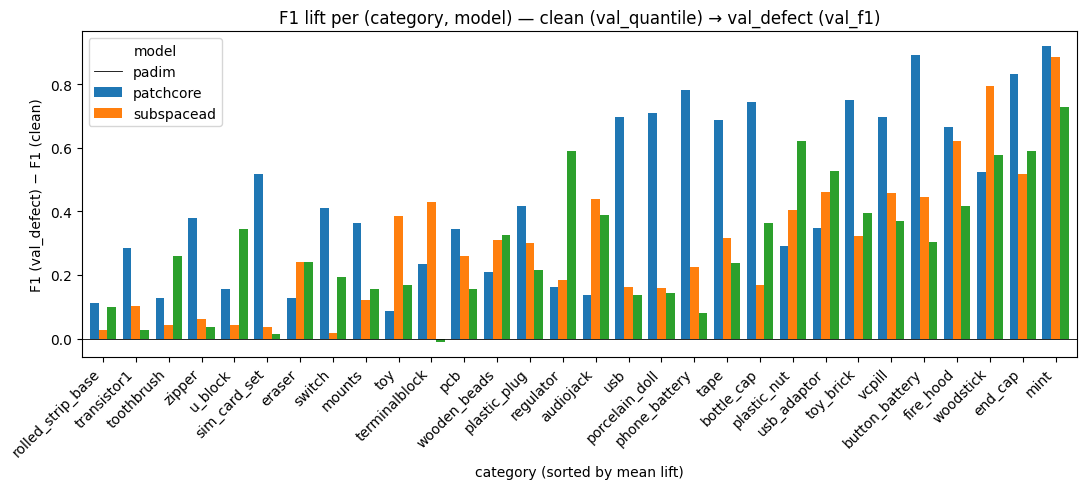

In [14]:
# F1-lift bar chart, sorted by mean lift across the 3 models.
lift = merged.pivot(index="category", columns="model", values="df1")
lift["_mean"] = lift.mean(axis=1)
lift = lift.sort_values("_mean")
lift = lift.drop(columns="_mean")

fig, ax = plt.subplots(figsize=(11, 5))
lift.plot(kind="bar", ax=ax, width=0.8)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_ylabel("F1 (val_defect) − F1 (clean)")
ax.set_xlabel("category (sorted by mean lift)")
ax.set_title("F1 lift per (category, model) — clean (val_quantile) → val_defect (val_f1)")
ax.legend(title="model", labels=[m.replace("anomalib_", "") for m in lift.columns])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

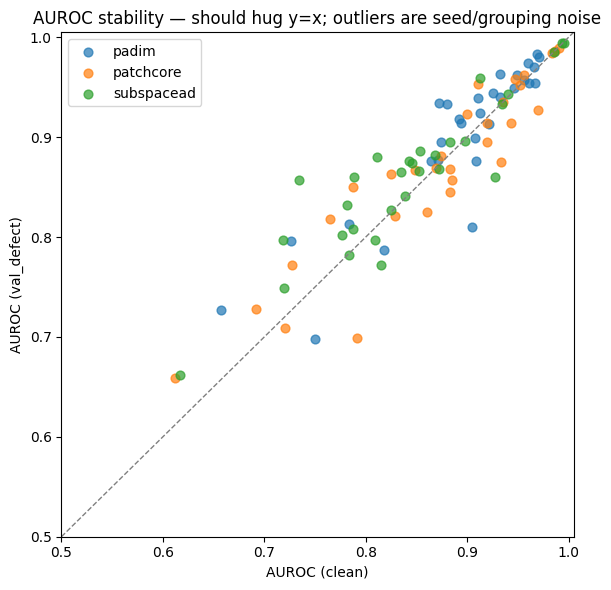

In [15]:
# AUROC stability scatter: clean vs val_defect, identity line = perfect stability.
fig, ax = plt.subplots(figsize=(6, 6))
for m, sub in merged.groupby("model"):
    ax.scatter(sub["auroc_clean"], sub["auroc_vd"],
               label=m.replace("anomalib_", ""), s=40, alpha=0.7)
lims = [0.5, 1.005]
ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("AUROC (clean)")
ax.set_ylabel("AUROC (val_defect)")
ax.set_title("AUROC stability — should hug y=x; outliers are seed/grouping noise")
ax.legend()
plt.tight_layout()
plt.show()

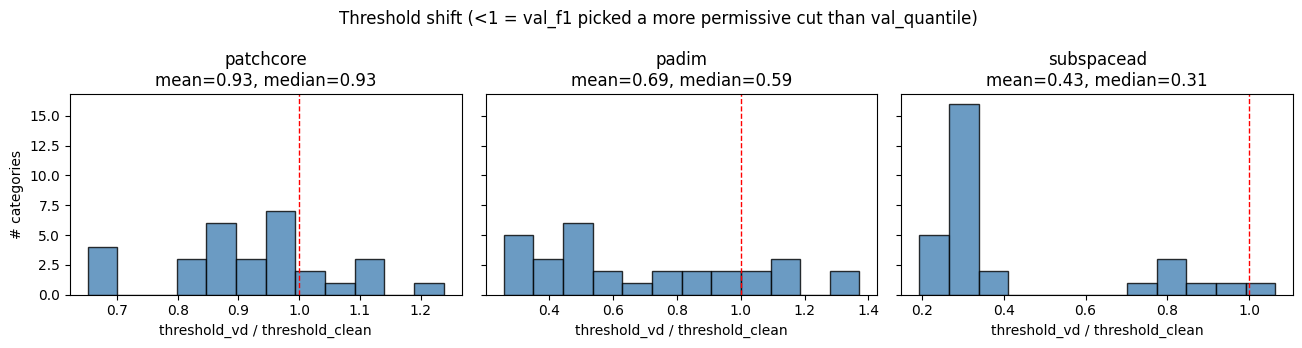

In [16]:
# Threshold-shift histogram per model (val_f1 / val_quantile ratio).
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, m in zip(axes, FEATURE_MODELS):
    sub = merged[merged["model"] == m]["thr_ratio"]
    ax.hist(sub.dropna(), bins=12, color="steelblue", edgecolor="black", alpha=0.8)
    ax.axvline(1.0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{m.replace('anomalib_', '')}\nmean={sub.mean():.2f}, median={sub.median():.2f}")
    ax.set_xlabel("threshold_vd / threshold_clean")
axes[0].set_ylabel("# categories")
fig.suptitle("Threshold shift (<1 = val_f1 picked a more permissive cut than val_quantile)")
plt.tight_layout()
plt.show()

---

## Pointers

- Source plan: [PLAN job A_analize val_defect.md](../PLAN%20job%20A_analize%20val_defect.md)
- Methodology context: [METHOD.md §2 + §7](../METHOD.md)
- Companion notebook: [compare jobB vs jobA.ipynb](compare%20jobB%20vs%20jobA.ipynb)
- TSV outputs land under `data/outputs/jobA_val_defect_V1/_analysis/`.